# Práctica 4: Procesamiento del Lenguaje Natural

__Fecha de entrega: 16 de mayo de 2025__

El objetivo de esta práctica es aplicar los conceptos teóricos vistos en clase en el módulo de PLN.

Lo más importante en esta práctica no es el código Python, sino el análisis de los datos y modelos que construyas y las explicaciones razonadas de cada una de las decisiones que tomes. __No se valorarán trozos de código o gráficas sin ningún tipo de contexto o explicación__.

Finalmente, recuerda establecer el parámetro `random_state` en todas las funciones que tomen decisiones aleatorias para que los resultados sean reproducibles (los resultados no varíen entre ejecuciones).

**GRUPO N**

DANIEL CASQUERO PALENCIA

LUIS OROFINO ÁLVAREZ

In [1]:
RANDOM_STATE = 1234

# 1) Carga del conjunto de datos

Los ficheros `fake.csv` y `true.csv` contienen artícuos de noticias clasificadas como fake (falsas) o true (reales) respectivamente. Cada noticia tiene como atributos:

*   Title: título de la noticia
*   Text: cuerpo del texto de la noticia
*   Subject: tema de la noticia
*   Date: fecha de publicación de la noticia

Muestra un ejemplo de cada clase.

Haz un estudio del conjunto de datos. ¿qué palabras aparecen más veces?, ¿tendría sentido normalizar de alguna manera el corpus?

Crea una partición de los datos dejando el 60% para entrenamiento, 20% para validación y el 20% restante para test. Comprueba que la distribución de los ejemplos en las particiones es similar.

In [2]:
import pandas as pd

# Cargar el conjunto de datos
df_fake = pd.read_csv('./fake.csv')
df_true = pd.read_csv('./true.csv')

In [3]:
#Mostramos un ejemplo de cada clase
df_fake.iloc[0]

title       Donald Trump Sends Out Embarrassing New Year’...
text       Donald Trump just couldn t wish all Americans ...
subject                                                 News
date                                       December 31, 2017
Name: 0, dtype: object

In [4]:
df_true.iloc[0]

title      As U.S. budget fight looms, Republicans flip t...
text       WASHINGTON (Reuters) - The head of a conservat...
subject                                         politicsNews
date                                      December 31, 2017 
Name: 0, dtype: object

In [5]:
import string

In [6]:
# Función para limpiar y contar palabras
def count_words(text):
    # Convertir texto a minúsculas
    text = text.lower()
    
    # Eliminar signos de puntuación
    text = ''.join([char for char in text if char not in string.punctuation])
    
    # Dividir el texto en palabras
    words = text.split()
    # Contar las palabras y actualizar el diccionario word_count
    for word in words:
        if word in word_count:
            word_count[word] += 1
        else:
            word_count[word] = 1

In [7]:
text_fake = df_fake['text']
word_count = {}
text_fake.apply(count_words)
most_common_words_fake = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

text_true = df_true['text']
word_count = {}
text_true.apply(count_words)
most_common_words_true = sorted(word_count.items(), key=lambda x: x[1], reverse=True)

#Mostramos el número total de palabras en los dataframes
print("Número de palabras en el dataframe False: ")
num_fake = 0
for word,count in most_common_words_fake[:]:
    num_fake += count 
print(num_fake)

print("Número de palabras en el dataframe True: ")
num_true = 0
for word,count in most_common_words_true[:]:
    num_true += count 
print(num_true)

Número de palabras en el dataframe False: 
9922814
Número de palabras en el dataframe True: 
8217189


In [8]:
# Mostrar las 15 palabras más comunes de cada dataframe
print("Palabras más comunes en el dataframe Fake:")
for word, count in most_common_words_fake[:15]:
    print(f"{word}: {count}")
print("\nPalabras más comunes en el dataframe True:")
for word, count in most_common_words_true[:15]:
    print(f"{word}: {count}")

Palabras más comunes en el dataframe Fake:
the: 526628
to: 289551
of: 235728
and: 224311
a: 210277
in: 164258
that: 149893
s: 129447
is: 110685
for: 91918
on: 81164
it: 78328
he: 77314
trump: 73422
was: 67704

Palabras más comunes en el dataframe True:
the: 478239
to: 244707
of: 204852
a: 196734
and: 181304
in: 180047
on: 108134
said: 99017
that: 86277
for: 79494
is: 55170
with: 54274
he: 52597
was: 47876
by: 47558


In [9]:
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

wpt = nltk.WordPunctTokenizer()
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('english')

def normalize_document(doc):
    # lower case and remove special characters\whitespaces
    doc = re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)
    doc = doc.lower()
    doc = doc.strip()
    # tokenize document
    tokens = wpt.tokenize(doc)
    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]
    # re-create document from filtered tokens
    doc = ' '.join(filtered_tokens)
    return doc

normalize_corpus = np.vectorize(normalize_document)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lorof\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Normalizamos los datos
datos_normalizados = normalize_corpus(df_fake['text'].values)

cv = CountVectorizer(max_features=5000)
cv_matrix = cv.fit_transform(datos_normalizados)
cv_matrix = cv_matrix.toarray()
suma_columnas = cv_matrix.sum(axis = 0)
indice_columna_maxima = np.argmax(suma_columnas)

nombres_columnas = cv.get_feature_names_out()

print(f"La palabra más repetida en el dataframe Fake es '{nombres_columnas[indice_columna_maxima]}'.")
print(f"Se repite un total de {np.max(suma_columnas)} veces.")

C:\Users\lorof\AppData\Local\Temp\ipykernel_16956\2877722948.py:12: DeprecationWarning: 'count' is passed as positional argument
  doc = re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)


La palabra más repetida en el dataframe Fake es 'trump'.
Se repite un total de 74011 veces.


En este caso tiene sentido normalizar el corpus. Ya que con esto haremos que se consideren iguales palabras como "run" y "running", lo que tiene sentido y mejora la eficiencia de modelos como Naive-Bayes o TF-IDF que utlizaremos más adelante. También se eliminan palabras vacías, como "the", "a", etc, que no aportan nada de cara al estudio. 

Después de la normalización vemos que la palabra más repetida en el dataframe True.csv es "said", y en Fake.csv "Trump".

In [11]:
# Normalizamos los datos
datos_normalizados = normalize_corpus(df_true['text'].values)

cv_matrix = cv.fit_transform(datos_normalizados)
cv_matrix = cv_matrix.toarray()
suma_columnas = cv_matrix.sum(axis = 0)
indice_columna_maxima = np.argmax(suma_columnas)

nombres_columnas = cv.get_feature_names_out()

print(f"La palabra más repetida  en el dataframe True es '{nombres_columnas[indice_columna_maxima]}'.")
print(f"Se repite un total de {np.max(suma_columnas)} veces.")

C:\Users\lorof\AppData\Local\Temp\ipykernel_16956\2877722948.py:12: DeprecationWarning: 'count' is passed as positional argument
  doc = re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)


La palabra más repetida  en el dataframe True es 'said'.
Se repite un total de 99040 veces.


In [12]:
#Unimos los dataframes en el mismo conjunto de datos
#Creo una nueva columna para distinguir las fake de las true
df_fake['label'] = 'FAKE'
df_true['label'] = 'TRUE'

df = pd.concat([df_true, df_fake], ignore_index=True)

In [13]:
from sklearn.model_selection import train_test_split

# Primero dividimos en 60% train y 40% resto
df_train, df_temp = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

# Luego dividimos ese 40% en validación y test (20% cada uno del total)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42
)

# Mostrar tamaños
print(f"Train: {len(df_train)} ejemplos")
print(f"Validación: {len(df_val)} ejemplos")
print(f"Test: {len(df_test)} ejemplos")


Train: 26938 ejemplos
Validación: 8980 ejemplos
Test: 8980 ejemplos


In [14]:
print("Distribución en entrenamiento:")
print(df_train['label'].value_counts(normalize=True))

print("\nDistribución en validación:")
print(df_val['label'].value_counts(normalize=True))

print("\nDistribución en test:")
print(df_test['label'].value_counts(normalize=True))

Distribución en entrenamiento:
label
FAKE    0.524241
TRUE    0.475759
Name: proportion, dtype: float64

Distribución en validación:
label
FAKE    0.523163
TRUE    0.476837
Name: proportion, dtype: float64

Distribución en test:
label
FAKE    0.519042
TRUE    0.480958
Name: proportion, dtype: float64


# 2) Representación como bolsa de palabras

Elige justificadamente una representación de bolsa de palabras y aplícala.
Muestra un ejemplo antes y después de aplicar la representación. Explica los cambios.

In [15]:
import numpy.ma as ma

def write_terms (feature_names, data, vector_data, index):
    '''
    Escribe los términos presentes en un texto representado como bolsa de palabras.

    - feature_names: terminos usados para vectorizar
    - data: lista de mensajes original (si data==None no se muestra el mensaje original)
    - vector_data: matriz (dispersa) de mensaje vectorizados
    - index: posición del mensaje a mostrar
    '''
    # máscara para seleccionar sólo el mensaje en posición index
    mask=vector_data[index,:]>0

    # términos que aparecen en ese mensaje vectorizado
    terminos = ma.array(feature_names, mask = ~(mask[0].toarray()))

    # mostrar mensaje original
    if data is not None:
        print('Texto', index, ':', data[index])

    # mostrar términos que aparecen en el mensaje vectorizado
    print('\nTexto', index, 'vectorizado:', terminos.compressed(),'\n')

In [16]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer


vectorizer = CountVectorizer(stop_words='english')

# Tomamos los textos del conjunto de entrenamiento y los transformamos en
# una matriz de datos (palabras) según el diccionario estándar
train_vector_data = vectorizer.fit_transform(df_train['text'])

# Sacamos las palabras asociadas a los vectores
feature_names = vectorizer.get_feature_names_out()

tfidfer = TfidfTransformer()
train_preprocessed = tfidfer.fit_transform(train_vector_data)

In [17]:
#Mostramos un ejemplo antes y despues de aplicar la representación
write_terms(feature_names, df_train['text'].values, train_preprocessed, 738)

Texto 738 : Will Megyn Kelly be working towards a  gotcha moment  that has the press talking about her the next day, or will she focus on more serious issues facing Americans? Fox News  Megyn Kelly will moderate her second GOP presidential primary debate on Jan. 28, just days before the Iowa caucuses, the network announced Monday.The seventh scheduled showdown between the GOP candidates, which will be held at the Iowa Events Center in Des Moines, will air at 9:00 p.m. EST.The network hasn t explained yet how candidates can qualify to participate in the last debate before the Iowa caucuses.Fox s Bret Baier and Chris Wallace will also return for a second time to moderate along with Kelly. The three anchors moderated the first GOP debate on Aug. 6, which ended with Trump accusing Kelly of unfair treatment. Via: Washington Examiner

Texto 738 vectorizado: ['00' '28' 'accusing' 'air' 'americans' 'anchors' 'announced' 'aug'
 'baier' 'bret' 'candidates' 'caucuses' 'center' 'chris' 'day' 'days

Los cambios que han sucedido entre el original y el transformado son los siguientes:
- Eliminación de los *signos de puntuación*, pues no aportan significado semántico relevante a la hora de clasificar un texto.
- Transformación del texto en *minúsculas*, para poder identificar palabras iguales escritas en mayúsculas o en minúsculas.
- Eliminación de palabras que no aportan ningún significado relevante al mensaje, es decir **stopwords** (por ejemplo: "the", "at", "a"...). Estas se eliminan para no confundir a la red neuronal y darle sólo los datos relevantes.
  
En resumen, se guardan las palabras semánticamente relevantes y se eliminan las stopwords.

# 3) Aplica 3 algoritmos de aprendizaje automático para resolver la tarea

Justifica porqué los has elegido.
Ajusta los modelos respecto a un hiperparámetro que consideres oportuno. Justifica tu elección.
Explica los resultados obtenidos.

In [28]:
# Transformamos train, val y test
X_train_vec = vectorizer.fit_transform(df_train['text'])
X_train_tfidf = tfidfer.fit_transform(X_train_vec)

X_val_vec = vectorizer.transform(df_val['text'])
X_val_tfidf = tfidfer.transform(X_val_vec)

X_test_vec = vectorizer.transform(df_test['text'])
X_test_tfidf = tfidfer.transform(X_test_vec)

***NAIVE BAYES***

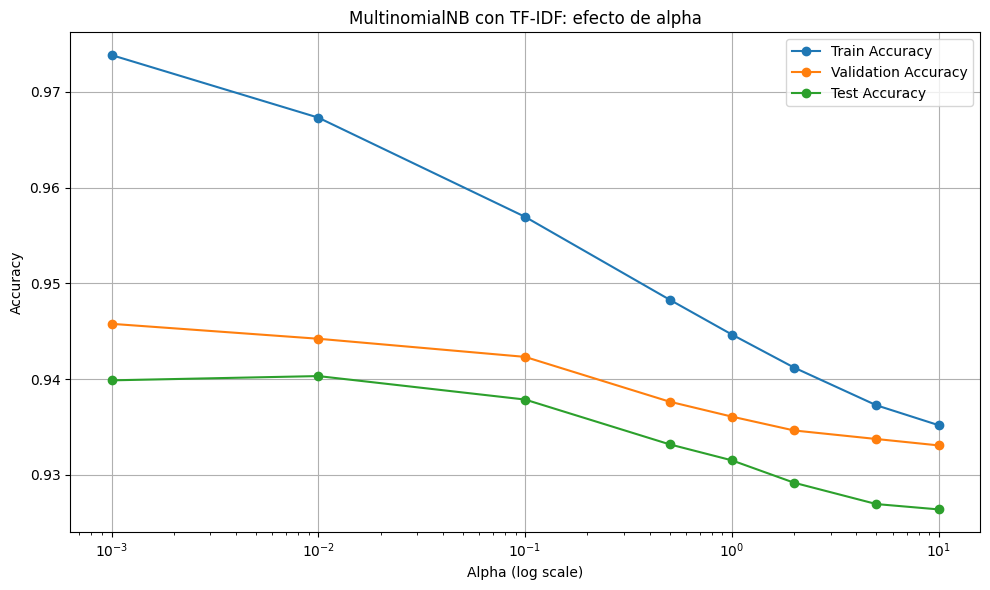

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Probar distintos valores de alpha
alpha_vals = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
train_accuracies = []
val_accuracies = []
test_accuracies = []

for alpha in alpha_vals:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tfidf, df_train['label'])

    train_pred = model.predict(X_train_tfidf)
    val_pred = model.predict(X_val_tfidf)
    test_pred = model.predict(X_test_tfidf)

    train_accuracies.append(accuracy_score(df_train['label'], train_pred))
    val_accuracies.append(accuracy_score(df_val['label'], val_pred))
    test_accuracies.append(accuracy_score(df_test['label'], test_pred))

# 4. Graficar
plt.figure(figsize=(10, 6))
plt.plot(alpha_vals, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(alpha_vals, val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(alpha_vals, test_accuracies, label='Test Accuracy', marker='o')

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Accuracy')
plt.title('MultinomialNB con TF-IDF: efecto de alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
# Entrenar el modelo con Multinomial Naive Bayes
nb_classifier = MultinomialNB(alpha=0.001) # Puedes ajustar alpha si quieres

nb_classifier.fit(X_train_tfidf, df_train['label'].values)

# Predicciones en entrenamiento y test
nb_train_predictions = nb_classifier.predict(X_train_tfidf)
nb_val_predictions = nb_classifier.predict(X_val_tfidf)
nb_test_predictions = nb_classifier.predict(X_test_tfidf)

# Mostrar accuracies
print("Multinomial Naive Bayes - Precisión en entrenamiento:", np.mean(nb_train_predictions == df_train['label'].values))
print("Multinomial Naive Bayes - Precisión en validación:", np.mean(nb_val_predictions == df_val['label'].values))
print("Multinomial Naive Bayes - Precisión en test:", np.mean(nb_test_predictions == df_test['label'].values))


Multinomial Naive Bayes - Precisión en entrenamiento: 0.973828792040983
Multinomial Naive Bayes - Precisión en validación: 0.9457683741648107
Multinomial Naive Bayes - Precisión en test: 0.9398663697104677


***SVM***

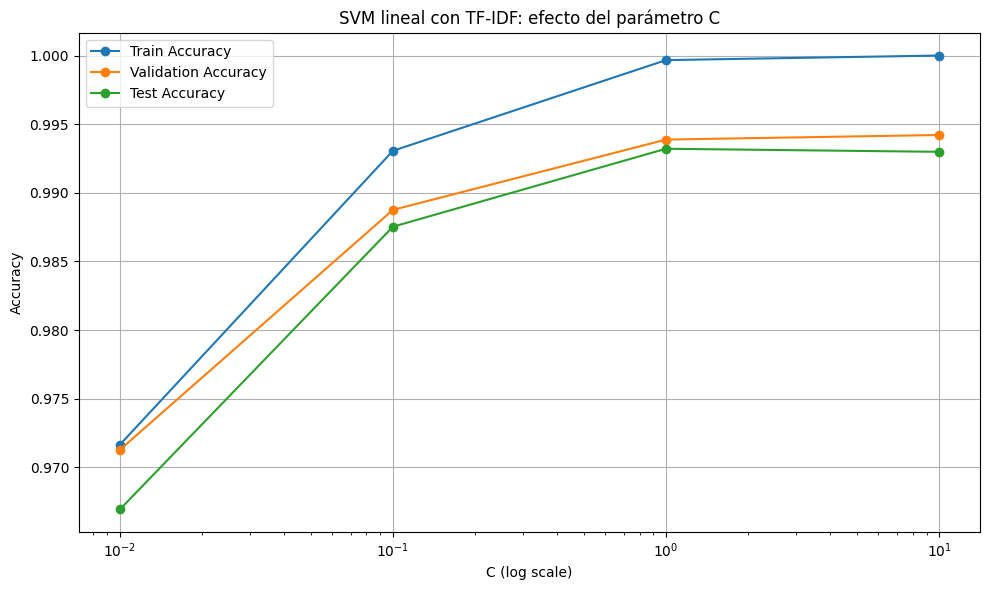

In [31]:
from sklearn.svm import LinearSVC

# Lista de valores de C a probar
C_vals = [0.01, 0.1, 1, 10]
train_accuracies = []
val_accuracies = []
test_accuracies = []

for C in C_vals:
    model = LinearSVC(C=C, max_iter=10000)  # max_iter aumentado por si tarda
    model.fit(X_train_tfidf, df_train['label'])

    y_train_pred = model.predict(X_train_tfidf)
    y_val_pred = model.predict(X_val_tfidf)
    y_test_pred = model.predict(X_test_tfidf)

    train_accuracies.append(accuracy_score(df_train['label'], y_train_pred))
    val_accuracies.append(accuracy_score(df_val['label'], y_val_pred))
    test_accuracies.append(accuracy_score(df_test['label'], y_test_pred))

# Paso 3: Plot
plt.figure(figsize=(10, 6))
plt.plot(C_vals, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(C_vals, val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(C_vals, test_accuracies, label='Test Accuracy', marker='o')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('SVM lineal con TF-IDF: efecto del parámetro C')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Entrenar el modelo con SVM
svm =  LinearSVC(C=10, max_iter=10000)

svm.fit(X_train_tfidf, df_train['label'].values)

# Predicciones en entrenamiento y test
svm_train_predictions = svm.predict(X_train_tfidf)
svm_val_predictions = svm.predict(X_val_tfidf)
svm_test_predictions = svm.predict(X_test_tfidf)

# Mostrar accuracies
print("SVM - Precisión en entrenamiento:", np.mean(svm_train_predictions == df_train['label'].values))
print("SVM - Precisión en validación:", np.mean(svm_val_predictions == df_val['label'].values))
print("SVM - Precisión en test:", np.mean(svm_test_predictions == df_test['label'].values))

Multinomial Naive Bayes - Precisión en entrenamiento: 1.0
Multinomial Naive Bayes - Precisión en validación: 0.9942093541202672
Multinomial Naive Bayes - Precisión en test: 0.9929844097995546


***kNN***

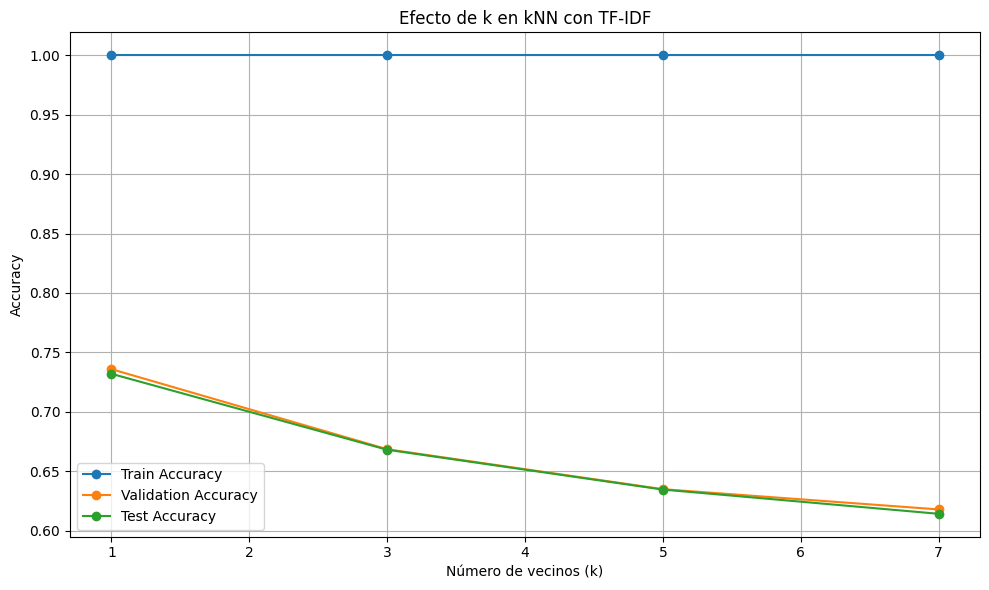

In [84]:
from sklearn.neighbors import KNeighborsClassifier

# Lista de valores de k a probar
k_vals = [1, 3, 5, 7]
train_accuracies = []
val_accuracies = []
test_accuracies = []

for k in k_vals:
    model = KNeighborsClassifier(n_neighbors=k, weights = 'distance')
    model.fit(X_train_tfidf, df_train['label'])

    y_train_pred = model.predict(X_train_tfidf)
    y_val_pred = model.predict(X_val_tfidf)
    y_test_pred = model.predict(X_test_tfidf)

    train_accuracies.append(accuracy_score(df_train['label'], y_train_pred))
    val_accuracies.append(accuracy_score(df_val['label'], y_val_pred))
    test_accuracies.append(accuracy_score(df_test['label'], y_test_pred))

# Paso 3: Gráfica
plt.figure(figsize=(10, 6))
plt.plot(k_vals, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_vals, val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(k_vals, test_accuracies, label='Test Accuracy', marker='o')

plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy')
plt.title('Efecto de k en kNN con TF-IDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [86]:
# Entrenar el modelo con SVM
knn =  KNeighborsClassifier(n_neighbors=1,  weights='distance')#RELLENAR

knn.fit(X_train_tfidf, df_train['label'].values)

# Predicciones en entrenamiento y test
knn_train_predictions = knn.predict(X_train_tfidf)
knn_val_predictions = knn.predict(X_val_tfidf)
knn_test_predictions = knn.predict(X_test_tfidf)

# Mostrar accuracies
print("kNN - Precisión en entrenamiento:", np.mean(knn_train_predictions == df_train['label'].values))
print("kNN - Precisión en validación:", np.mean(knn_val_predictions == df_val['label'].values))
print("kNN - Precisión en test:", np.mean(knn_test_predictions == df_test['label'].values))

KeyboardInterrupt: 

# 4) Construye redes neuronales con Keras con distintas maneras de usar word embeddings

Justifica tus decisiones y explica los resultados obtenidos.

In [53]:
#from keras.preprocessing.text import Tokenizer
#from keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence


max_words = 1500
max_comment_length = 300 #ponemos una longitud media de 300 palabras por noticia



df['label'] = df['label'].replace({'TRUE': 1, 'FAKE': 0})


tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])

word_index = tokenizer.word_index
print('Se han encontrado %s tokens únicos.' % len(word_index))
max_words = len(word_index)

data = sequence.pad_sequences(sequences, maxlen=max_comment_length)

Se han encontrado 138021 tokens únicos.


In [55]:
print(df['text'][738])
print(data[738])

WASHINGTON (Reuters) - The U.S. Senate Banking Committee will hold a confirmation hearing on Nov. 28 for Jerome Powell, President Donald Trump’s nominee for chairman of the Federal Reserve, the committee said in a statement on Wednesday. Trump last week tapped Powell, 64, a Fed governor since 2012, to become head of the U.S. central bank, breaking with precedent by denying Janet Yellen a second four-year term but signaling a continuation of her cautious monetary policies. Powell is quickly garnering support from Republican lawmakers, including Senate Majority Leader Mitch McConnell, who met with Powell on Tuesday and said he looked forward to “supporting his nomination.” Republican Senator Mike Crapo, who chairs the Banking Committee, said on Wednesday that Powell was “well-equipped to lead our economy and the country in a positive direction.” Powell is widely expected to continue to raise interest rates gradually, as Yellen began to do in late 2015, and to shrink the central bank’s $4

Vemos que el tokenizador ha transformado el texto de arriba en el vector de abajo. El vector de abajo tiene 300 componentes (max_comment_length), que se rellenan con los números asociados a los tokens que ha procesado el tokenizador. Al haberle puesto limitado al tokenizador el número de palabras en su vocabulario a 1500 (max_words), sólo tiene las 1500 palabras más comunes. Por lo que si aparece alguna palabra del texto que no esté entre estas 1500 palabras no será reconocida y no aparecerá con un número positivo en el vector.

Aun así, el texto de esta noticia tiene 211 palabras, pero vemos que el vector solo aparecen 125 posiciones distintas de 0. Es decir, 211-125=86 palabras del texto no estaban entre las 1500 del vocabulario del tokenizador. El resto de posiciones con 0 se han rellenado automáticamente para alcanzar el tamaño del vector impuesto (300).

Es decir, estos vectores de datos son creados con números asociados a los tokens de las palabras del texto y, si este número de tokens es menor que el tamaño de dicho vector (en este caso, 300), se rellenan con 0 las primeras posiciones hasta completarlo.

In [54]:
from sklearn.model_selection import train_test_split

#valor de random state
rs=333

d=df.values

x_train, x_test, y_train, y_test = train_test_split(
    data,                 # Datos de entrada (los textos ya convertidos a vectores con `pad_sequences`)
    df['label'],          # Etiquetas (0 para FAKE, 1 para REAL)
    test_size=0.20,       # 20% de los datos para test
    random_state=rs,      # Semilla de aleatoriedad
    stratify=df['label']  # Asegura que la proporción de clases se mantenga en train y test
)

print("Textos de entrenamiento:", len(y_train))
print("Testear textos:", len(y_test))

Textos de entrenamiento: 35918
Testear textos: 8980


In [56]:
# Fijamos el tamaño de los embedding a 50 dimensiones
embedding_dim = 50

Fijamos el tamaño de los vectores de word-embedding a 50. Es decir, las palabras estarán representadas por vectores con 50 componentes.

Este es un tamaño relativamente pequeño, pero que nos aportará rapidez de ejecución. No necesitamos un tamaño mayor porque la complejidad del problema no lo requiere. Podríamos usar un tamaño mayor si tuviésemos ordenadores más potentes con más capacidad de ejecución, pero no hace falta.

__MODELO 1. SIN EMBEDDINGS PRE-ENTRENADOS__

Primero, usaremos un modelo sin embeddings pre-entrenados. Esto quiere decir que la red neuronal aprenderá los vectores de las palabras desde cero. Usará directamente los datos que le hemos metido en lugar de modelos pre-entrenados que ya conocen el significado de las palabras (como los que usaremos más adelante).

Este modelo parte de vectores aleatorios y los ajustará durante el entrenamiento. Es por esto por lo que va a ser el modelo que más tarde en ejecutarse: debe ir aprendiendo a medida que se ejecuta.

In [57]:
# MODELO 1. SIN EMBEDDINGS PRE-ENTRENADOS

from keras.models import Sequential
from keras.layers import Flatten, Dense, Embedding

model1 = Sequential()

model1.add(Embedding(max_words, embedding_dim))

model1.add(Flatten())

# Añadimos el clasificador
model1.add(Dense(1, activation='sigmoid'))

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

history = model1.fit(x_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(x_test, y_test))

score1 = model1.evaluate(x_test, y_test)

print("Precisión: %.2f%%" % (score1[1]*100))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape     ┃  Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ embedding (Embedding) │ ?                │        0 │
│                       │                  │ (unbuil… │
├───────────────────────┼──────────────────┼──────────┤
│ flatten (Flatten)     │ ?                │        0 │
│                       │                  │ (unbuil… │
├───────────────────────┼──────────────────┼──────────┤
│ dense (Dense)         │ ?                │        0 │
│                       │                  │ (unbuil… │
└───────────────────────┴──────────────────┴──────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 96s 84ms/step - accuracy: 0.9005 - loss: 0.2166 - val_accuracy: 0.9925 - val_loss: 0.0243
Epoch 2/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 138s 81ms/step - accuracy: 0.9954 - loss: 0.0150 - val_accuracy: 0.9923 - val_loss: 0.0244
Epoch 3/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 95s 84ms/step - accuracy: 0.9982 - loss: 0.0085 - val_accuracy: 0.9942 - val_loss: 0.0185
Epoch 4/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 101s 90ms/step - accuracy: 0.9999 - loss: 0.0019 - val_accuracy: 0.9937 - val_loss: 0.0200
Epoch 5/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 93s 83ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9945 - val_loss: 0.0202
Epoch 6/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 140s 81ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9925 - val_loss: 0.0271
Epoch 7/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 146s 84ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9933 - val_loss: 0.0263
Epoch 8/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 86s 77ms/step - accuracy: 0.99

__CON EMBEDDINGS PRE-ENTRENADOS__

En los dos siguientes modelos, usaremos embeddings pre-entrenados. Es decir, usarán vecotres de palabras que ya han sido previamente entrenados, como es el caso de GloVe. Estos vectores ya "entienden" el significado de las palabras que procesen.

Posteriormente, usaremos un embeding con congelamiento y otro sin él.

In [22]:
# CON EMBEDDINGS PRE-ENTRENADOS
import os
import numpy as np

glove_dir = '.'

embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.50d.txt'), encoding='utf-8')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Se han encontrado %s vectores de palabras.' % len(embeddings_index))

FileNotFoundError: [Errno 2] No such file or directory: '.\\glove.6B.50d.txt'

In [63]:
embedding_dim = 50

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # La palabras no encontradas serán 0.
            embedding_matrix[i] = embedding_vector

__MODELO 2. EMBEDDINGS PRE-ENTRENADOS CONGELADOS__

Usamos un embedding pre-entrenado congelado. Es decir, este modelo pre-entrenado usa los vectores pre-entrenados tal y como están. No los modifica durante el entrenamiento (los congela). 

Veremos después que este embedding no es el mejor, pues está confiando plenamente en un embedding pre-entrenado en unas condiciones que no se ajustan a las de nuestro ejemplo en concreto, por lo que será mejor aquellos que sí que se ajusten a nuestro caso.

En el código, el congelamiento lo vemos reflejado cuando haces que _trainable_ sea False.

Como ventaja, este modelo será el que menos tarde, pues no tiene que hacer ajsutes a medida que avanza el entrenamiento.

In [64]:
# MODELO 2. EMBEDDINGS PRE-ENTRENADOS CONGELADOS

# from keras.models import Sequential  # DEPRECATED
from tensorflow.keras.models import Sequential
# from keras.layers import Embedding, Flatten, Dense  # DEPRECATED
from tensorflow.keras.layers import Embedding, Flatten, Dense


# Debugging prints
print(f"max_words: {max_words}, embedding_dim: {embedding_dim}, max_comment_length: {max_comment_length}")
print(f"embedding_matrix shape: {embedding_matrix.shape}")

model2 = Sequential()
model2.add(Embedding(max_words, embedding_dim, input_length=max_comment_length))
# model2.add(Embedding(max_words, embedding_dim, input_length=max_comment_length, weights=embedding_matrix))

# Check if weights exist before setting them
print("Layer weights before setting:", model2.layers[0].weights)

# Build the model (just in case)
model2.build(input_shape=(None, max_comment_length))

model2.add(Flatten())
model2.add(Dense(1, activation='sigmoid'))
model2.summary()

max_words: 138021, embedding_dim: 50, max_comment_length: 300
embedding_matrix shape: (138021, 50)
Layer weights before setting: []


C:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape     ┃  Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ embedding_1           │ (None, 300, 50)  │ 6,901,0… │
│ (Embedding)           │                  │          │
├───────────────────────┼──────────────────┼──────────┤
│ flatten_1 (Flatten)   │ (None, 15000)    │        0 │
├───────────────────────┼──────────────────┼──────────┤
│ dense_1 (Dense)       │ (None, 1)        │   15,001 │
└───────────────────────┴──────────────────┴──────────┘

 Total params: 6,916,051 (26.38 MB)

 Trainable params: 6,916,051 (26.38 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# Ensure shape matches before setting weights
if embedding_matrix.shape == (max_words, embedding_dim):
    model2.layers[0].set_weights([embedding_matrix])
    model2.layers[0].trainable = False
else:
    print("Error: embedding_matrix has incorrect shape.")

In [66]:
model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model2.fit(x_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(x_test, y_test))

score2 = model2.evaluate(x_test, y_test)
print("Precisión: %.2f%%" % (score2[1]*100))

Epoch 1/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8760 - loss: 0.2913 - val_accuracy: 0.9365 - val_loss: 0.1774
Epoch 2/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9669 - loss: 0.1065 - val_accuracy: 0.9472 - val_loss: 0.1569
Epoch 3/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9802 - loss: 0.0714 - val_accuracy: 0.9476 - val_loss: 0.1651
Epoch 4/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9876 - loss: 0.0512 - val_accuracy: 0.9545 - val_loss: 0.1592
Epoch 5/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9905 - loss: 0.0404 - val_accuracy: 0.9479 - val_loss: 0.1881
Epoch 6/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9911 - loss: 0.0343 - val_accuracy: 0.9531 - val_loss: 0.1761
Epoch 7/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9944 - loss: 0.0255 - val_accuracy: 0.9504 - val_loss: 0.1930
Epoch 8/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9972 - loss: 0.019

__MODELO 3. EMBEDDINGS PREENTRENADOS SIN CONGELAR__

Por último, usaremos un embedding pre-entrenado sin congelar. Es decir, activamos _trainable_ a True y eso hará que el modelo pueda aprender durante el entrenamiento. 

Parte de un modelo ya entrenado pero lo modifica durante la ejecución con el fin de adaptarlo a nuestro caso en concreto.

Como desventaja respecto al anterior, tiene mucho mayor coste computacional y se ve reflejado en su tiempo de ejecución.

In [69]:
# MODELO3. EMBEDDINGS PREENTRENADOS SIN CONGELAR


model3 = Sequential()
model3.add(Embedding(max_words, embedding_dim, input_length=max_comment_length))
model3.add(Flatten())
model3.add(Dense(1, activation='sigmoid'))
model3.summary()

model3.build(input_shape=(None, max_comment_length))
model3.layers[0].set_weights([embedding_matrix])
model3.layers[0].trainable = True

model3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model3.fit(x_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(x_test, y_test))

score3 = model3.evaluate(x_test, y_test)
print("Precisión: %.2f%%" % (score3[1]*100))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape     ┃  Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ embedding_3           │ ?                │        0 │
│ (Embedding)           │                  │ (unbuil… │
├───────────────────────┼──────────────────┼──────────┤
│ flatten_3 (Flatten)   │ ?                │        0 │
│                       │                  │ (unbuil… │
├───────────────────────┼──────────────────┼──────────┤
│ dense_3 (Dense)       │ ?                │        0 │
│                       │                  │ (unbuil… │
└───────────────────────┴──────────────────┴──────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - accuracy: 0.9122 - loss: 0.2089 - val_accuracy: 0.9852 - val_loss: 0.0430
Epoch 2/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 59s 52ms/step - accuracy: 0.9948 - loss: 0.0194 - val_accuracy: 0.9901 - val_loss: 0.0308
Epoch 3/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 59s 52ms/step - accuracy: 0.9995 - loss: 0.0047 - val_accuracy: 0.9912 - val_loss: 0.0277
Epoch 4/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 59s 52ms/step - accuracy: 0.9999 - loss: 0.0020 - val_accuracy: 0.9915 - val_loss: 0.0274
Epoch 5/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 61s 54ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.9921 - val_loss: 0.0287
Epoch 6/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 61s 54ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9886 - val_loss: 0.0541
Epoch 7/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 58s 51ms/step - accuracy: 0.9986 - loss: 0.0043 - val_accuracy: 0.9904 - val_loss: 0.0422
Epoch 8/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 61s 54ms/step - accuracy: 0.9994 -

In [70]:
print("RESUMEN DE LOS RESULTADOS OBTENIDOS")
print("Sin word embeddings pre-entrenados")
print("Accuracy: %.2f%%" % (score1[1]*100))
print("Con word embeddings pre-entrenados congelados")
print("Accuracy: %.2f%%" % (score2[1]*100))
print("Con word embeddings pre-entrenados sin congelar")
print("Accuracy: %.2f%%" % (score3[1]*100))

RESUMEN DE LOS RESULTADOS OBTENIDOS
Sin word embeddings pre-entrenados
Accuracy: 99.10%
Con word embeddings pre-entrenados congelados
Accuracy: 95.09%
Con word embeddings pre-entrenados sin congelar
Accuracy: 99.08%


Durante el entrenamiento de los word embeddings hemos obtenido estos resultados.

Como vemos, el que obtiene mayor precisión es el que no ha pre-entrenado los datos (99.10%), muy seguido del que usa datos pre-entrenados sin congelar (99.08%). La diferencia entre sus precisiones es tan pequeña que podemos decir que han obtenido los mismos resultados. 

En cambio, el modelo con menos precisión de todos es el pre-entrenado congelado (95.09%).

Estos resultados tienen sentido: los dos mejores modelos se ajustan al ejemplo concreto que tenemos en esta práctica, ya que ambos aprenden a medida que se ejecutan. Uno lo hace desde cero (el primero) y el otro parte de datos que han sido aprendidos en el pasado (el segundo). En cambio, el tercer modelo está congelado y no se le permite ir aprendiendo a medida que entrena. Por ello, tiene confianza plena en unos datos pre-entrenados que pueden no ajustarse al 100% al ejemplo este. 

# 5) Aplica los modelos construidos a los datos de test y compáralos.

Calcula las métricas de recall, precisión y f1.
Discute cual es el mejor modelo y cual es peor y porqué.

Veamos las métricas de cada uno de los 3 modelos y elijamos el mejor y el peor entre ellos.

Calcularemos 3 métricas:
- *precision*: esta métrica sirve para responder a la pregunta: "de todas las veces que el predictor ha dicho que una noticia es real, ¿cuántas era verdad?". Es decir, un valor alto nos indica que habrá pocos "falsos positivos", cosa que nos interesa.
- *recall*: esta métrica responde a lo siguiente: "de todos las noticias clasificadas como reales, ¿cuántas ha encontrado el predictor?". Un valor alto nos indicará pocos "falsos negativos". Esta métrica es muy importante si te interesa que nunca se pase por alto un valor verdadero (si fuese un error grave clasificar una noticia real como falsa, esta métrica sería la más relevante).
- *f1*: es la media armónica entre el _recall_ y la _precision_. Nos ayuda a ver el promedio entre ambos.

También mostraremos las matrices de confusión de cada modelo, que nos indicarán los números de verdaderos negativos, falsos negativos, verdaderos positivos y falsos positivos. Se sacan a partir de esta las métricas ya comentadas

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# Realizamos las predicciones sobre el conjunto de test
y_pred = model1.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)  # Convertimos las probabilidades a 0 o 1

# Generamos el reporte de clasificación
report = classification_report(y_test, y_pred, digits=4)
print("Reporte de clasificación:\n", report)

# También podemos generar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", conf_matrix)


NameError: name 'model1' is not defined

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

# Realizamos las predicciones sobre el conjunto de test
y_pred = model2.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)  # Convertimos las probabilidades a 0 o 1

# Generamos el reporte de clasificación
report = classification_report(y_test, y_pred, digits=4)
print("Reporte de clasificación:\n", report)

# También podemos generar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", conf_matrix)


281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Reporte de clasificación:
               precision    recall  f1-score   support

           0     0.9469    0.9600    0.9534      4696
           1     0.9554    0.9409    0.9481      4284

    accuracy                         0.9509      8980
   macro avg     0.9511    0.9505    0.9508      8980
weighted avg     0.9510    0.9509    0.9509      8980

Matriz de confusión:
 [[4508  188]
 [ 253 4031]]


In [71]:
from sklearn.metrics import classification_report, confusion_matrix

# Realizamos las predicciones sobre el conjunto de test
y_pred = model3.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)  # Convertimos las probabilidades a 0 o 1

# Generamos el reporte de clasificación
report = classification_report(y_test, y_pred, digits=4)
print("Reporte de clasificación:\n", report)

# También podemos generar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", conf_matrix)


281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Reporte de clasificación:
               precision    recall  f1-score   support

           0     0.9904    0.9919    0.9912      4696
           1     0.9911    0.9895    0.9903      4284

    accuracy                         0.9908      8980
   macro avg     0.9908    0.9907    0.9907      8980
weighted avg     0.9908    0.9908    0.9908      8980

Matriz de confusión:
 [[4658   38]
 [  45 4239]]


En los reportes de clasificación obtenemos de manera desglosada los porcentajes de cada métrica para las noticias falsas y las verdaderas, así como la media entre ambas y su media ponderada (debido a que no hay exactamente el mismo número de falsas que de reales). Esta media ponderada de cada métrica será el dato en el que nos vamos a fijar, pues es el que más nos muestra la realidad (aunque son todos los valores prácticamente idénticos).

Al obtener los tres resultados, tenemos algo prácticamente idéntico a lo que ya habíamos visto en el entrenamiento de los modelos. Los reportes con mayor precisión son los de los modelos sin pre-entrenar (99.10%) y el modelo pre-entrenado sin congelamiento (99.08%). Entre ellos no hay apenas diferencias: la matriz de confusión es igual en ambos para los falsos y, en las noticias reales, el modelo sin congelamiento ha dado 2 falsos positivos más que el sin pre-entreno. Es una diferencia tan pequeña respecto al número total de datos que es irrelevante. La razón por la que destacan estos modelos es la que ya hemos expuesto antes: son modelos que aprenden mientras se ejecutan, por lo que son capaces de adaptarse mucho más al ejemplo concreto en el que trabajamos. En ambos modelos se ha obtenido los mismos valores para las tres métricas analizadas. 

Por otro lado, el modelo pre-entrenado congelado es el que peores resultados ha obtenido (95.09% de precisión, y el mismo valor para las otras métricas). No obstante, hay que decir que es una precisión muy alta y que es un buen modelo, pero, en comparación con los otros dos, que son casi perfectos, este destaca negativamente. Esto se debe a que este modelo es rígido: no aprende a medida que avanza la ejecución y se fía totalmente de los datos pre-entrenados en otros casos. Por tanto, la poca adaptabilidad al caso que hemos dado es la que hace que este modelo sea el peor de los 3 en cuanto a métricas.

En cuanto a coste computacional es totalmente al revés: el modelo que menos tarda en ejecutarse, con mucha diferencia, es el pre-entrenado congelado. Los otros dos, han tardado mucho más, pues necesitaban ir aprendiendo a medida que se ejecutaba e ir cambiando las variables que les hiciesen tomar una decisión u otra. Por lo que, si no interesase tanto la precisión y más el poco tiempo de ejecución y una respuesta rápida, nuestra decisión sería clara: el pre-entrenado congelado (nos ofrece también una alta precisión, dentro de lo que cabe).

En cambio, como decisión final, nos quedamos con el **word embedding pre-entrenado sin congelar**, pues nos ofrece una precisión altísima (prácticamente igual que el sin pre-entreno) y tarda menos que el que no ha sido entrenado de antes, pues parte de datos fiables y no desde cero. Aun así, tiene un coste computacional mayor que el congelado, al que hemos elegido como peor modelo de los tres. En resumen, creemos que el mejor modelo es el que más precisión ofrece, pero que no tenga un coste computacional exageradamente alto (como el de sin pre-entrenar).